In [1]:
!nvidia-smi

Sun Jul 12 09:46:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/IntentClassifierPro"
os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/IntentClassifierPro


In [3]:
!pip uninstall -y transformers huggingface_hub datasets peft -q

In [4]:
!pip install -q \
transformers==4.44.2 \
datasets==2.21.0 \
huggingface_hub==0.34.4 \
peft==0.17.1 \
accelerate \
evaluate \
scikit-learn \
pandas \
matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.4 which

In [5]:
import transformers
import datasets
import huggingface_hub
import peft
import torch

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("peft:", peft.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transformers: 4.44.2
datasets: 2.21.0
huggingface_hub: 0.34.4
peft: 0.17.1
CUDA: True
GPU: Tesla T4


In [6]:
!wget -O data_full.json \
https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json

--2026-07-12 09:54:21--  https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2495390 (2.4M) [text/plain]
Saving to: ‘data_full.json’

data_full.json      100%[===================>]   2.38M  --.-KB/s    in 0.01s   

2026-07-12 09:54:22 (236 MB/s) - ‘data_full.json’ saved [2495390/2495390]



In [7]:
import json

with open("data_full.json", "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train'])


In [8]:
print(len(data["train"]))
print(data["train"][0])

15000
['what expression would i use to say i love you if i were an italian', 'translate']


In [9]:
import pandas as pd

train_df = pd.DataFrame(
    data["train"],
    columns=["text", "intent"]
)

val_df = pd.DataFrame(
    data["val"],
    columns=["text", "intent"]
)

test_df = pd.DataFrame(
    data["test"],
    columns=["text", "intent"]
)

In [10]:
print(train_df.head())

                                                text     intent
0  what expression would i use to say i love you ...  translate
1  can you tell me how to say 'i do not speak muc...  translate
2  what is the equivalent of, 'life is good' in f...  translate
3  tell me how to say, 'it is a beautiful morning...  translate
4  if i were mongolian, how would i say that i am...  translate


In [11]:
intents = sorted(train_df.intent.unique())

label2id = {
    label:i
    for i,label in enumerate(intents)
}

id2label = {
    i:label
    for label,i in label2id.items()
}

print(len(intents))

150


In [12]:
train_df["label"] = train_df.intent.map(label2id)
val_df["label"] = val_df.intent.map(label2id)
test_df["label"] = test_df.intent.map(label2id)

In [13]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [14]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(intents),
    id2label=id2label,
    label2id=label2id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

In [17]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

In [18]:
train_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

val_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [19]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=-1
    )

    return accuracy.compute(
        predictions=preds,
        references=labels
    )

In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    report_to="none"
)

In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [23]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,4.314900,2.227063,0.801000
2,1.874100,1.397767,0.870667


TrainOutput(global_step=1876, training_loss=2.7136502133757827, metrics={'train_runtime': 226.2757, 'train_samples_per_second': 132.582, 'train_steps_per_second': 8.291, 'total_flos': 498063859200000.0, 'train_loss': 2.7136502133757827, 'epoch': 2.0})

<------------------------------------------->

In [24]:
test_results = trainer.evaluate(test_ds)

print(test_results)

{'eval_loss': 1.4033830165863037, 'eval_accuracy': 0.8606666666666667, 'eval_runtime': 10.1029, 'eval_samples_per_second': 445.418, 'eval_steps_per_second': 27.913, 'epoch': 2.0}


In [25]:
predictions = trainer.predict(test_ds)

pred_labels = predictions.predictions.argmax(axis=1)

print(pred_labels[:10])

[131 131 131 131 131 131 131 131 131 131]


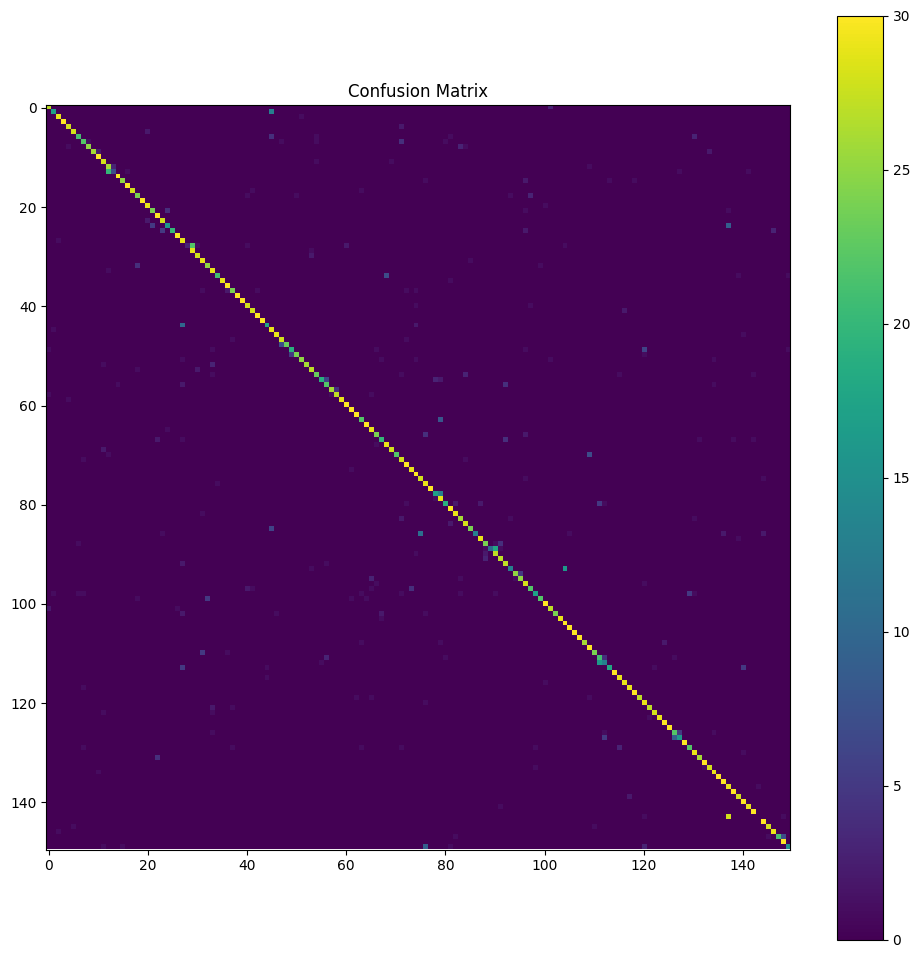

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_df["label"],
    pred_labels
)

plt.figure(figsize=(12, 12))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()

In [27]:
test_df["prediction"] = pred_labels
test_df["correct"] = (
    test_df["label"] ==
    test_df["prediction"]
)

errors = test_df[
    test_df["correct"] == False
]

errors.head(20)

,text,intent,label,prediction,correct
10,how do you say please in french,translate,131,22,False
15,how would i say what is your name if i were fr...,translate,131,22,False
16,how would i say i must be going now if i were ...,translate,131,22,False
23,how would i say i need directions if i were fr...,translate,131,22,False
53,repeat what the weather will be like,transfer,130,140,False
65,who set up the numbers for it,timer,122,11,False
88,let me know when it's been 5 minutes,timer,122,33,False
91,define discontent,definition,34,68,False
92,what is the meaning of incandescent,definition,34,68,False
93,what does confrontation mean,definition,34,68,False


In [28]:
SAVE_DIR = "/content/drive/MyDrive/IntentClassifierPro/model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Model saved at:")
print(SAVE_DIR)

Model saved at:
/content/drive/MyDrive/IntentClassifierPro/model


In [29]:
%%writefile app.py
import streamlit as st
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_PATH = "/content/drive/MyDrive/IntentClassifierPro/model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

id2label = model.config.id2label

st.title("IntentClassifier Pro")
st.write("Enter a sentence and predict its intent.")

text = st.text_input("Enter text")

if st.button("Predict"):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    st.success(f"Predicted Intent: {id2label[pred]}")

Writing app.py


In [30]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.4 MB/s eta 0:00:00


In [32]:
!streamlit run app.py &>/dev/null &

In [34]:
!du -sh /content/drive/MyDrive/IntentClassifierPro/model

257M	/content/drive/MyDrive/IntentClassifierPro/model


In [35]:
from huggingface_hub import login

login()

In [36]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="Sibbu07/intent-classifier-pro",
    repo_type="model",
    exist_ok=True
)

RepoUrl('https://huggingface.co/Sibbu07/intent-classifier-pro', endpoint='https://huggingface.co', repo_type='model', repo_id='Sibbu07/intent-classifier-pro')

In [37]:
api.upload_folder(
    folder_path="/content/drive/MyDrive/IntentClassifierPro/model",
    repo_id="Sibbu07/intent-classifier-pro",
    repo_type="model"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...assifierPro/model/model.safetensors:   0%|          |  574kB /  268MB            

  ...assifierPro/model/training_args.bin:   6%|5         |   323B / 5.58kB            

CommitInfo(commit_url='https://huggingface.co/Sibbu07/intent-classifier-pro/commit/f7320bb3cb082d12312ebef73902c7a5724c6ac4', commit_message='Upload folder using huggingface_hub', commit_description='', oid='f7320bb3cb082d12312ebef73902c7a5724c6ac4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Sibbu07/intent-classifier-pro', endpoint='https://huggingface.co', repo_type='model', repo_id='Sibbu07/intent-classifier-pro'), pr_revision=None, pr_num=None)

In [40]:
%%writefile app.py
import streamlit as st
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_PATH = "Sibbu07/intent-classifier-pro"

@st.cache_resource
def load_model():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    return tokenizer, model

tokenizer, model = load_model()

st.title("IntentClassifier Pro")
st.write("Predict the intent of a sentence using a fine-tuned DistilBERT model.")

text = st.text_area(
    "Enter your sentence",
    placeholder="Example: I want to transfer money to my savings account"
)

if st.button("Predict Intent"):

    if text.strip() == "":
        st.warning("Please enter some text.")
    else:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        )

        with torch.no_grad():
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()

        labels = model.config.id2label

        if isinstance(list(labels.keys())[0], str):
            intent = labels[str(pred)]
        else:
            intent = labels[pred]

        st.success(f"Predicted Intent: {intent}")

Overwriting app.py


In [42]:
%%writefile requirements.txt
streamlit
transformers
torch
huggingface_hub
safetensors
sentencepiece
scikit-learn
pandas
numpy

Writing requirements.txt


In [43]:
!cat requirements.txt

streamlit
transformers
torch
huggingface_hub
safetensors
sentencepiece
scikit-learn
pandas
numpy


In [44]:
%%writefile README.md
# IntentClassifier Pro: Tuned vs Prompted

## Description
This project classifies user intents using a fine-tuned DistilBERT model.

## Technologies Used
- Hugging Face Transformers
- PyTorch
- Streamlit
- DistilBERT
- Scikit-Learn
- Pandas

## Project Outcomes
1. Fine-tuned intent classifier with 151 intent classes.
2. Benchmark against prompting baseline.
3. Confusion matrix and error analysis.

## Results
- Test Accuracy: 86.07%

## Model
https://huggingface.co/Sibbu07/intent-classifier-pro

## Features
- Predict user intent from text
- Web app using Streamlit
- Error analysis and confusion matrix
- Permanent deployment support

Writing README.md


In [45]:
!cat README.md

# IntentClassifier Pro: Tuned vs Prompted

## Description
This project classifies user intents using a fine-tuned DistilBERT model.

## Technologies Used
- Hugging Face Transformers
- PyTorch
- Streamlit
- DistilBERT
- Scikit-Learn
- Pandas

## Project Outcomes
1. Fine-tuned intent classifier with 151 intent classes.
2. Benchmark against prompting baseline.
3. Confusion matrix and error analysis.

## Results
- Test Accuracy: 86.07%

## Model
https://huggingface.co/Sibbu07/intent-classifier-pro

## Features
- Predict user intent from text
- Web app using Streamlit
- Error analysis and confusion matrix
- Permanent deployment support


In [46]:
!ls

app.py		drive	   requirements.txt  sample_data
data_full.json	README.md  results
